In [54]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import dill
from tqdm import tqdm
import os

from analyze.report import plot_sound, POPULATION_COLORS, draw_spikes_and_psth_bothside, draw_rate_vs_cue, plot_tonotopic_heatmaps
from utils.custom_sounds import Tone, Click_Train, WhiteNoise
import brian2 as b2
import brian2hears as b2h

In [55]:
results_dir = '/Users/francescodesantis/Documents/repos/sound_localization_model/results/artificial_itd/'
#'/g100_work/EIRI_E_POLIM2/desa/sound_localization_model/results/' 
#'/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/sl_results/'
#'/Users/francescodesantis/Documents/repos/sound_localization_model/results/'

In [56]:
# List directory contents
items = os.listdir(results_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)


0 .DS_Store
1 click_train_interval_5. ms_70dB&seed_42_delay_1.28.pic
2 click_train_interval_5. ms_70dB&seed_42_delay_1.78.pic
3 click_train_interval_5. ms_70dB&test_lso_w_1_tau_0.5.pic
4 tone_250.Hz_56dB&seed_42_delay_0.78.pic
5 tone_250.Hz_56dB&seed_42_delay_1.28.pic
6 tone_250.Hz_56dB&seed_42_delay_1.78.pic
7 tone_250.Hz_56dB&seed_43_delay_0.78.pic
8 tone_250.Hz_56dB&seed_44_delay_0.78.pic
9 tone_250.Hz_56dB&seed_45_delay_0.78.pic
10 tone_250.Hz_56dB&seed_46_delay_0.78.pic
11 tone_250.Hz_56dB&seed_47_delay_0.78.pic
12 tone_250.Hz_56dB&seed_48_delay_0.78.pic
13 tone_250.Hz_56dB&seed_49_delay_0.78.pic
14 tone_250.Hz_56dB&seed_50_delay_0.78.pic
15 tone_250.Hz_56dB&test_lso_w_1_tau_0.5.pic
16 tone_250.Hz_59dB&w_12_wi_-30_seed_42.pic
17 tone_250.Hz_59dB&w_12_wi_-30_seed_43.pic
18 tone_250.Hz_59dB&w_12_wi_-30_seed_44.pic
19 tone_250.Hz_59dB&w_12_wi_-30_seed_45.pic
20 tone_250.Hz_59dB&w_12_wi_-30_seed_48.pic
21 tone_250.Hz_59dB&w_8_wi_-24_seed_42.pic
22 tone_250.Hz_59dB&w_8_wi_-24_seed_43.p

In [58]:
id_items = [4] + list(range(7,15))
results = []

for id in id_items:
    file_name = items[id]
    result_path = results_dir +  file_name

    with open(result_path, "rb") as file:
        result = dill.load(file, ignore=True)
    print(f"{file_name} loaded")
    results.append(result)

tone_250.Hz_56dB&seed_42_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_43_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_44_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_45_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_46_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_47_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_48_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_49_delay_0.78.pic loaded
tone_250.Hz_56dB&seed_50_delay_0.78.pic loaded


In [61]:

print(result['conf']['parameters']['SYN_WEIGHTS']['SBCs2MSO'])
print(result['conf']['parameters']['SYN_WEIGHTS']['MNTBCs2MSO'])

print(result['conf']['parameters']['TAUS_EX_RISE']['MSO'])
print(result['conf']['parameters']['TAUS_EX_DECAY']['MSO'])
print(result['conf']['parameters']['TAUS_IN_RISE']['MSO'])
print(result['conf']['parameters']['TAUS_IN_DECAY']['MSO'])


6
-15.0
0.5
1.0
0.2
0.5


original level: 56.41454852404224*dB
left level: 56.203125910152245*dB
right level: 56.203125910152245*dB


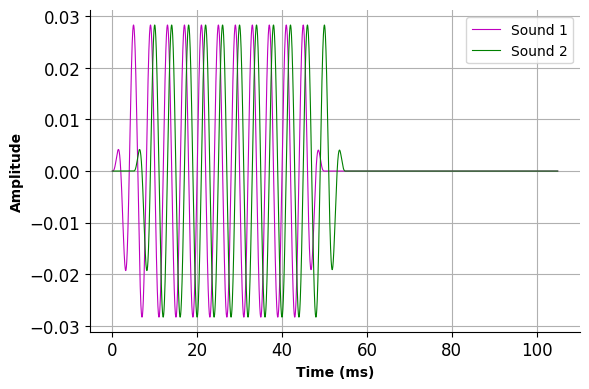

In [63]:
cue = -0.005
print("original level:", result['sounds']['base_sound'].sound.level)
plot_sound([result['sounds']['left_sounds'][cue], result['sounds']['right_sounds'][cue]], colors = [ 'm', 'g'])
print("left level:", result['sounds']['left_sounds'][cue].level)
print("right level:", result['sounds']['right_sounds'][cue].level)


In [64]:
if isinstance(result['sounds']['base_sound'], Tone):
    print("Base sound is a tone with frequency:", result['sounds']['base_sound'].frequency, "Hz")
    f = result['sounds']['base_sound'].frequency / b2.Hz
    CF_low  = f * 2**(-0.5)   
    CF_high = f * 2**(+0.5)   #4200 neurons around the CF, 2100 on each side
    cf_interval = [CF_low, CF_high]
    print(f"CF interval: {cf_interval[0]:.2f} Hz - {cf_interval[1]:.2f} Hz")
else:
    print("Base sound is not a tone, cannot determine CF interval.")
    cf_interval = None

d = max(
    max(result['sounds']['left_sounds'][cue].duration / b2.ms for cue in result['cue_to_rate']),
    max(result['sounds']['right_sounds'][cue].duration / b2.ms for cue in result['cue_to_rate'])
)
print("Max sound duration (ms):", d)

pop = 'LSO'
color = POPULATION_COLORS[pop]
bs = 0.5

Base sound is a tone with frequency: 250. Hz Hz
CF interval: 176.78 Hz - 353.55 Hz
Max sound duration (ms): 104.98


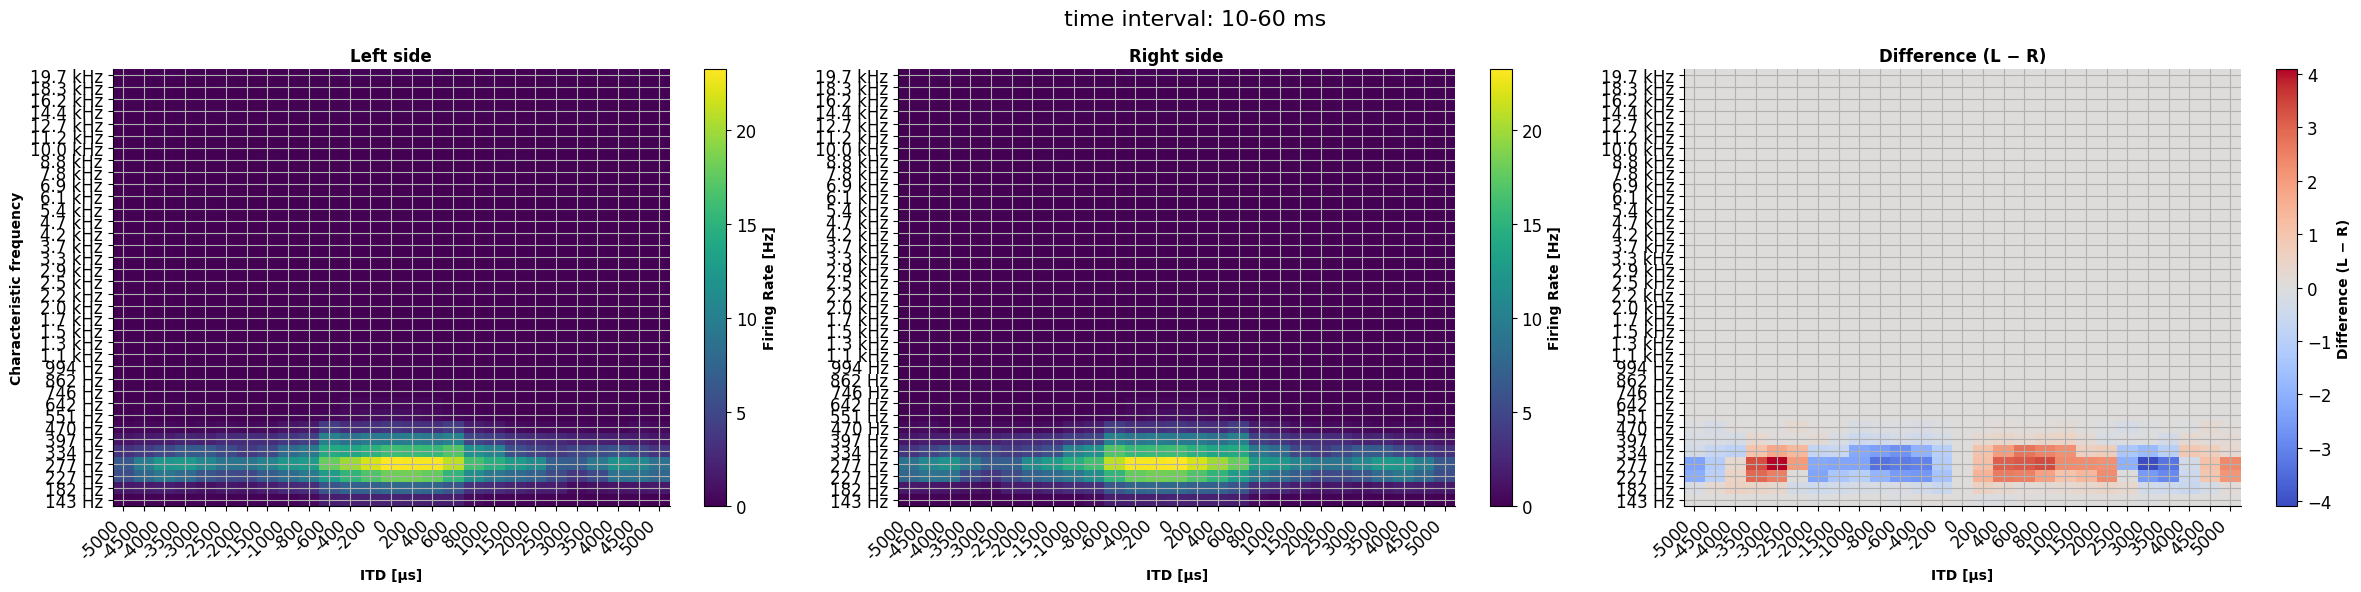

In [65]:
from analyze.report import plot_tonotopic_heatmaps

pop = 'MSO'
t = [10,60]
plot_tonotopic_heatmaps(
    data = result,
    pop = pop,
    num_cells_per_interval = 440,
    cue_type = 'itd',
    y_axis = 'cf',
    row_norm = False,
    show_sides = True,
    time_interval = t,
    title = f"time interval: {t[0]}-{t[1]} ms"
)

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


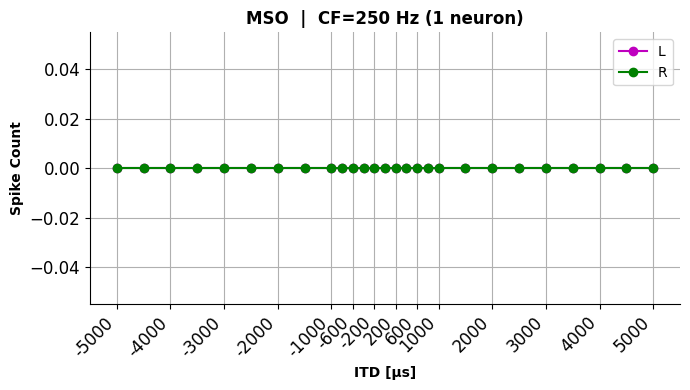

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


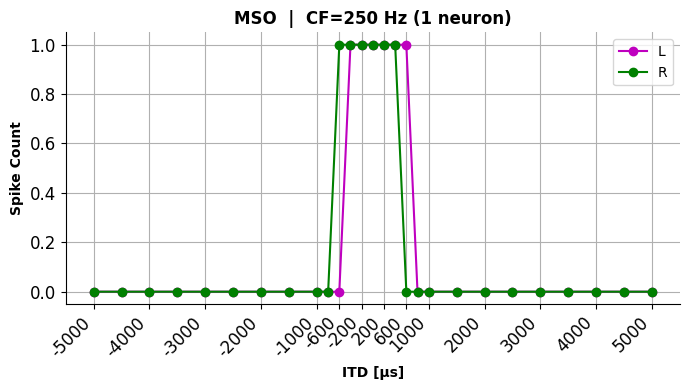

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


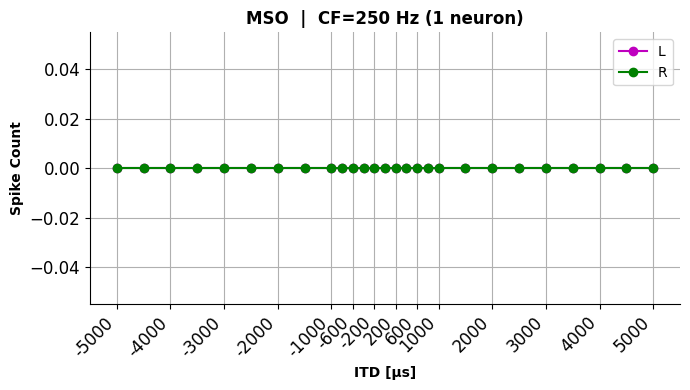

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


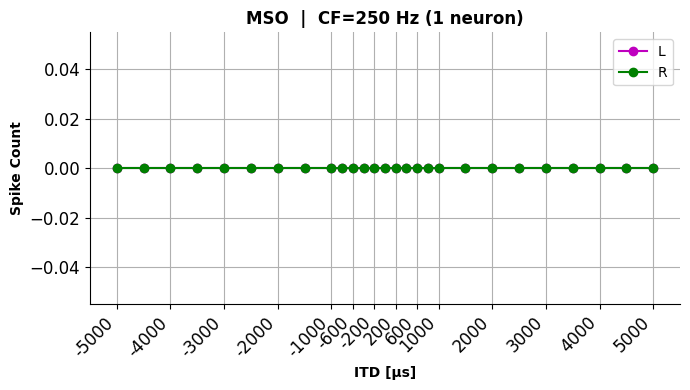

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


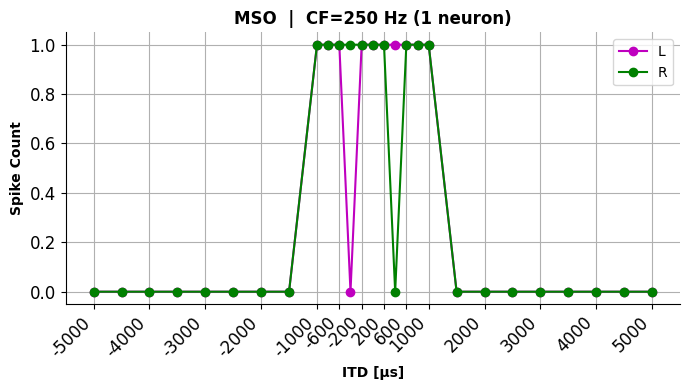

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


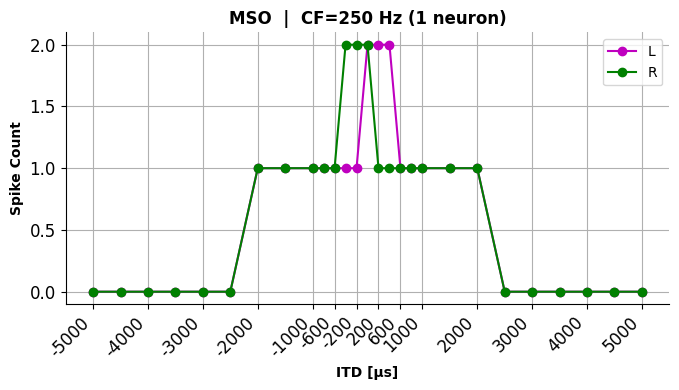

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


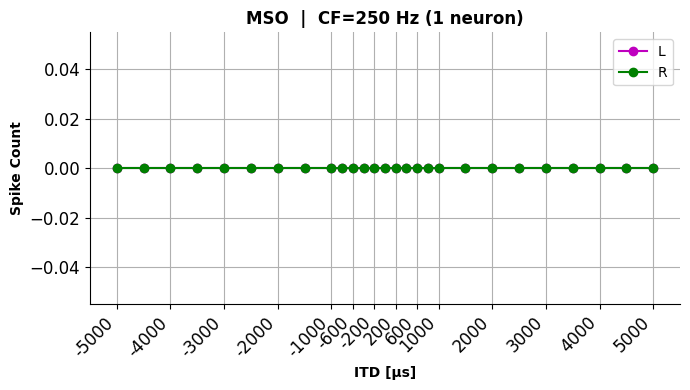

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


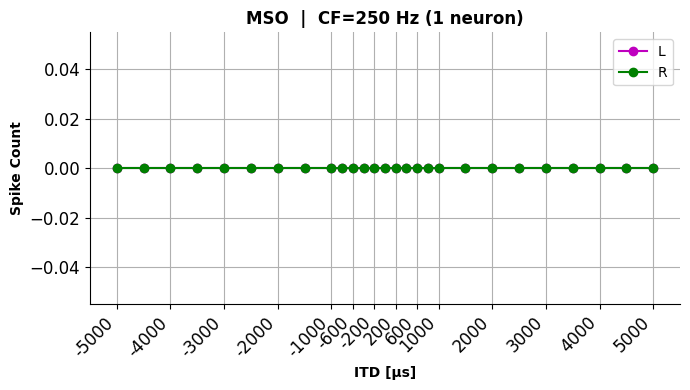

[draw_rate_vs_cue] target_cf_hz=250.0 Hz → neuron idx 1308 → cf_interval=[249.9, 250.0] Hz


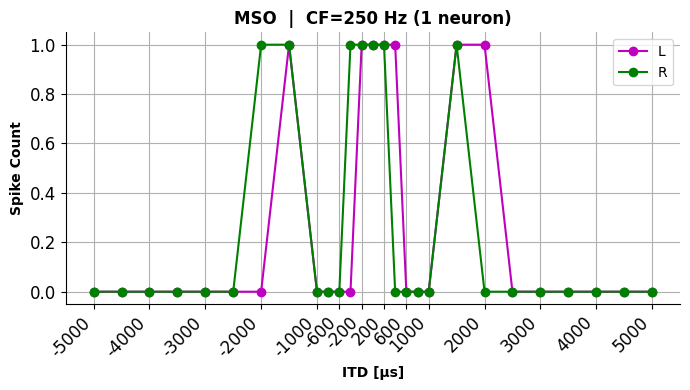

In [107]:
from analyze.report import draw_rate_vs_cue
for result in results:
    draw_rate_vs_cue(
        data=result,
        pop= pop,
        rate = 'count',
        cue_type = 'itd',
        target_cf_hz = f,
        cf_interval = cf_interval,
        )

In [100]:
result['cue_to_rate'][-0.002]['L']['MSO']['senders']

array([146272, 146104, 146118, 146020, 145684, 146272, 145936, 144368,
       144970, 146118, 146104, 146272, 144984, 145432, 145306, 145348,
       146188, 145334, 145250, 145138, 144970, 145152, 145250, 145236,
       145670, 145684, 144970, 145502, 146020, 145502, 145236, 144452,
       144970, 144984, 145404, 144368, 145404, 146272, 146272, 146202,
       144368, 146272, 144452, 145754, 147238, 146273, 145559, 145839,
       146357, 144873, 144355, 145307, 144439, 146273, 145125, 145209,
       145559, 145307, 144957, 145391, 144607, 145391, 144873, 145041,
       145391, 145559, 145391, 145293, 158355, 144957, 146007, 145125,
       145391, 145125, 146273, 145741, 145461, 145307, 145307, 146050,
       145812, 146498, 145196, 145294, 145210, 145546, 145560, 145280,
       145210, 145280, 145210, 145112, 145280, 145210, 144160, 145378,
       145196, 145112, 145560, 144958, 145378, 144748, 145210, 157278,
       144328, 144678, 145112, 144328, 144678, 146064, 145280, 145812,
      

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'LSO — side L (3 datasets)  |  t=[0,100] ms, CF=[12445,24890] Hz (622 neurons)'}, xlabel='ILD [dB]', ylabel='Avg Firing Rate [Hz]'>)

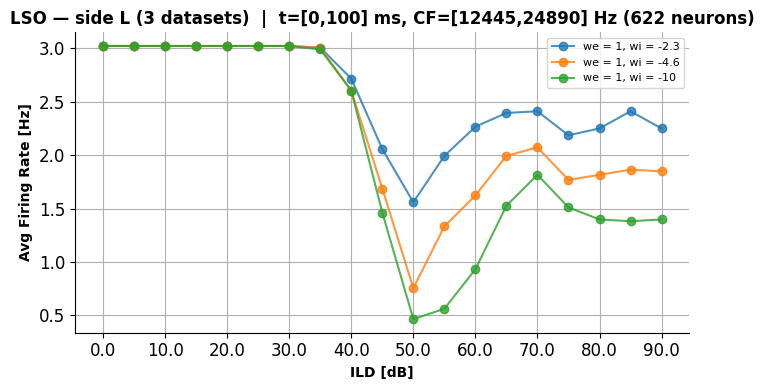

In [165]:
from analyze.report import draw_rate_vs_cue_multidata

draw_rate_vs_cue_multidata(
    data_list=results,
    side = 'L',
    pop= pop,
    rate = True,
    cue_type = 'ild',
    cf_interval = cf_interval,
    time_interval = [0,100],
    labels= ['we = 1, wi = -2.3', 'we = 1, wi = -4.6', 'we = 1, wi = -10'],# 'we = 2, wi = -20']#['C = 18.9 [WT MODEL]', 'C = 11.8 [HOM MODEL - %]', 'C = 14.18 [HOM REAL]', 'C = 22.72 [WT REAL]'], #'we = 1, wi = -2.3', 'we = 1, wi = -4.6'],# 'we = 2, wi = -20']#
    )

Avg firing rate (L side): 19.01 Hz
Avg firing rate (R side): 13.20 Hz


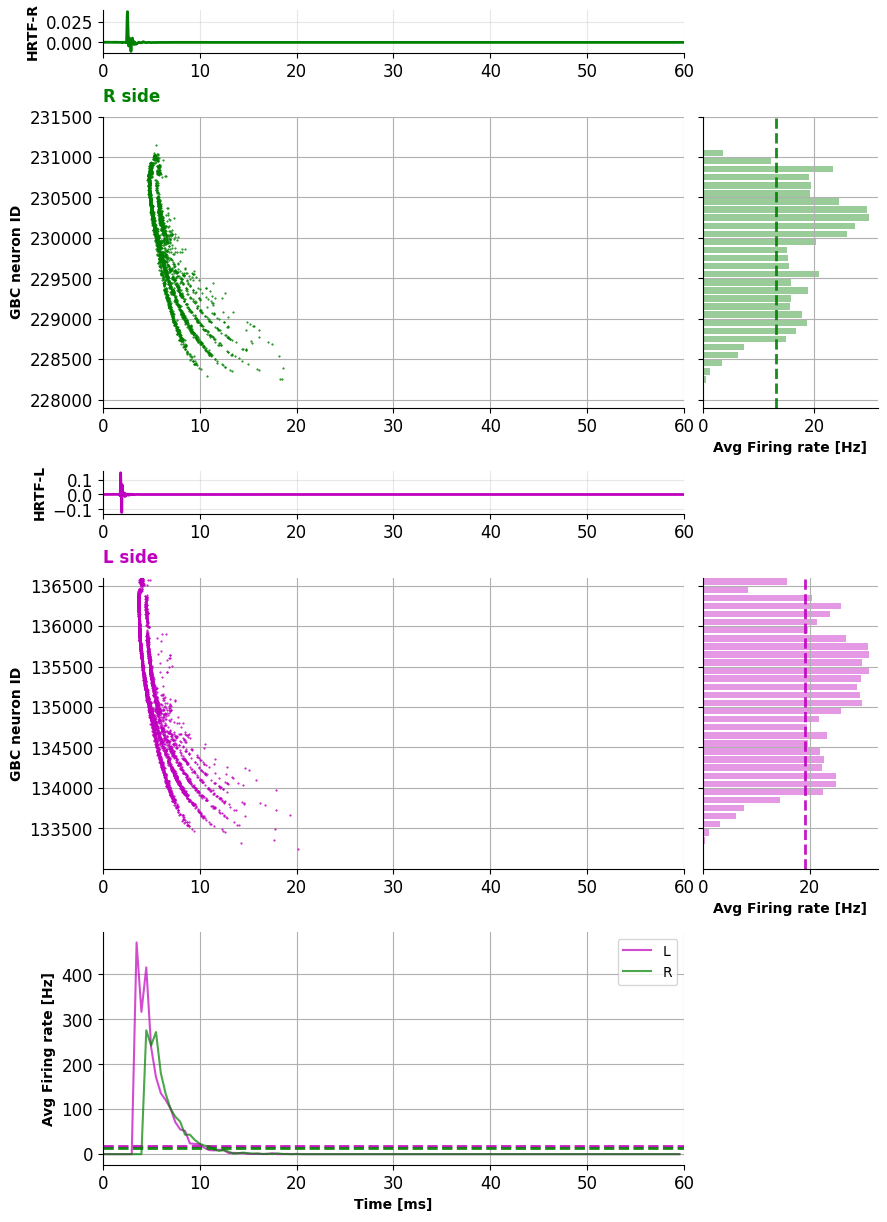

In [45]:
draw_spikes_and_psth_bothside(
    res=result,
    cue = cue,
    pop = 'GBC',
    y_ax='neurons',
    psth_bin_size=bs,
    cf_bin_size=100,
    hist_rate=True,
    figsize=(10,15),
    cf_interval=cf_interval
)


In [114]:
print(result['conf']['parameters']['SYN_WEIGHTS']['SBCs2LSO'])

print(result['conf']['parameters']['TAUS_EX_RISE']['LSO'])
print(result['conf']['parameters']['TAUS_EX_DECAY']['LSO'])
print(result['conf']['parameters']['TAUS_IN_RISE']['LSO'])
print(result['conf']['parameters']['TAUS_IN_DECAY']['LSO'])

print(result['conf']['parameters']['MEMB_CAPS']['LSO'])

0.8
0.5
1.0
0.2
1.0
12.0


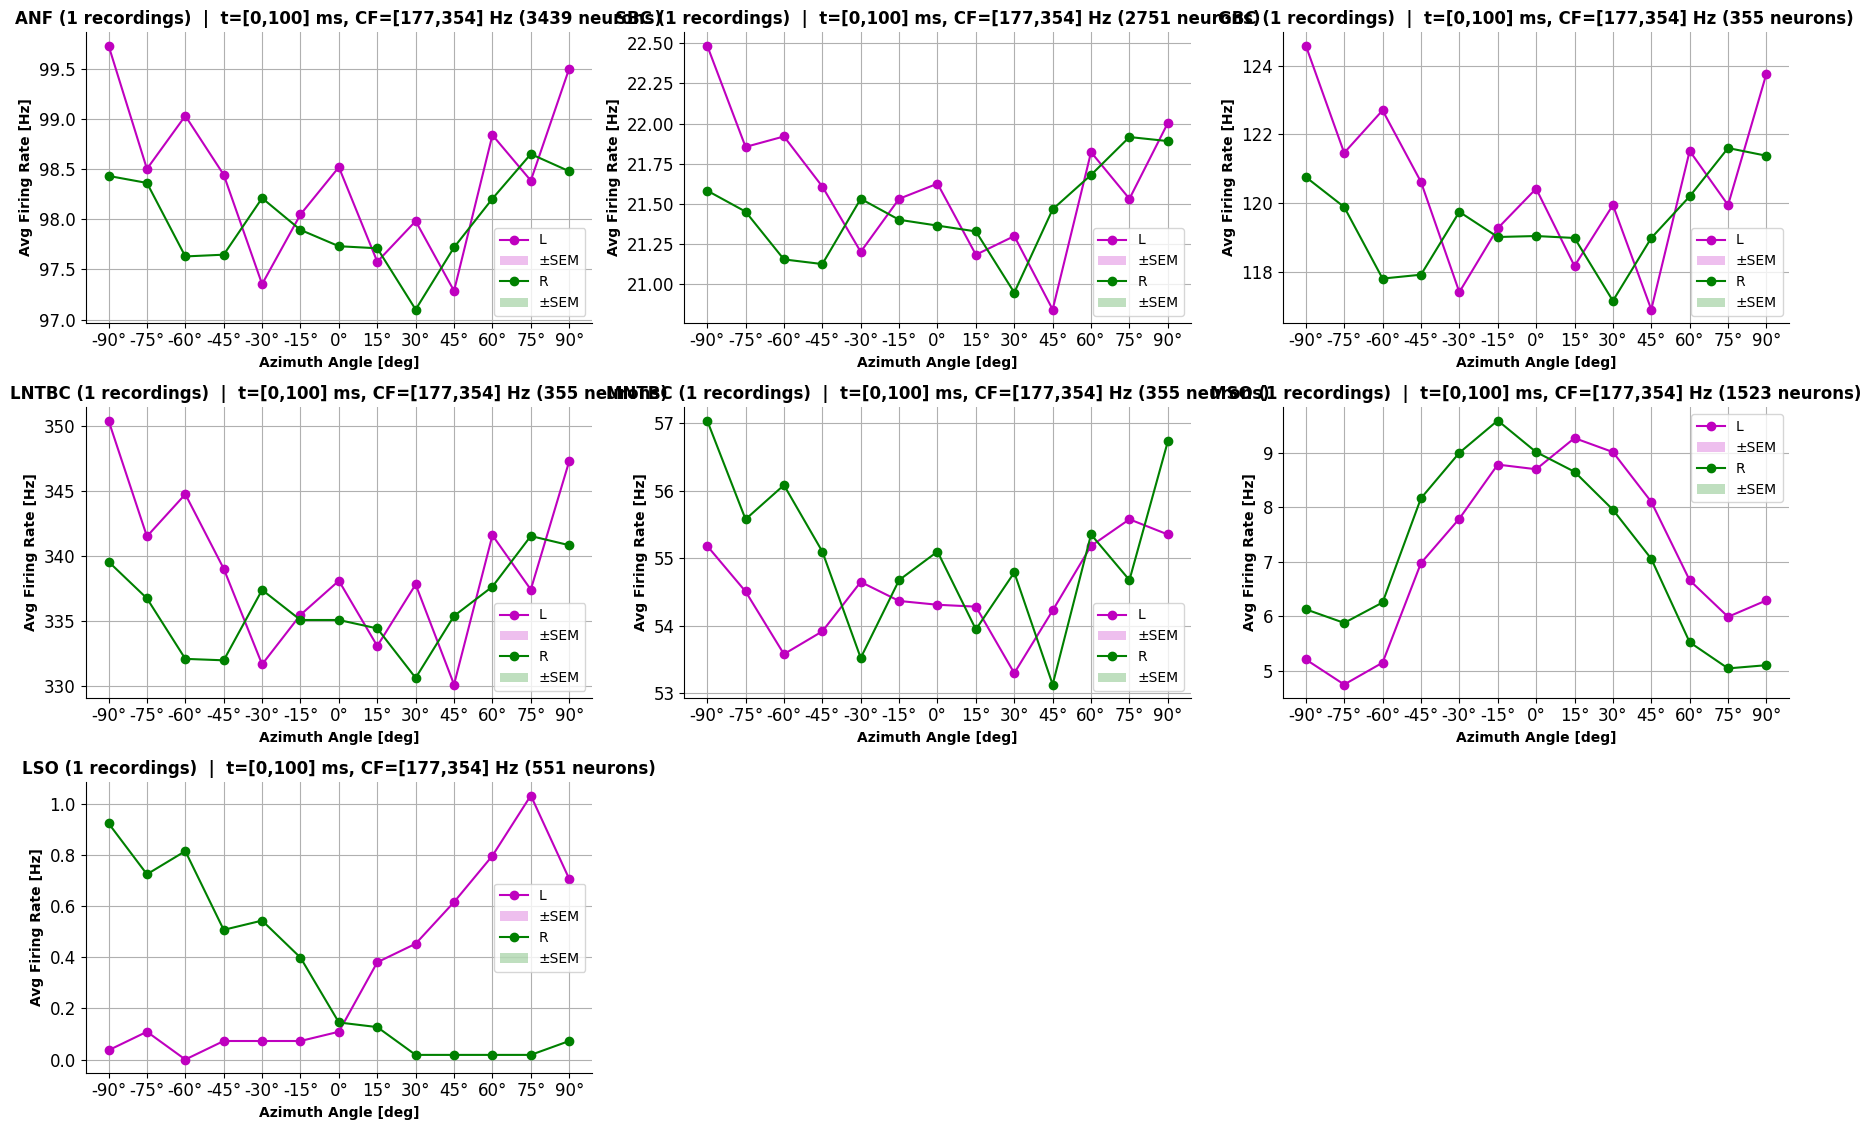

array([<Axes: title={'center': 'ANF (1 recordings)  |  t=[0,100] ms, CF=[177,354] Hz (3439 neurons)'}, xlabel='Azimuth Angle [deg]', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'SBC (1 recordings)  |  t=[0,100] ms, CF=[177,354] Hz (2751 neurons)'}, xlabel='Azimuth Angle [deg]', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'GBC (1 recordings)  |  t=[0,100] ms, CF=[177,354] Hz (355 neurons)'}, xlabel='Azimuth Angle [deg]', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'LNTBC (1 recordings)  |  t=[0,100] ms, CF=[177,354] Hz (355 neurons)'}, xlabel='Azimuth Angle [deg]', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'MNTBC (1 recordings)  |  t=[0,100] ms, CF=[177,354] Hz (355 neurons)'}, xlabel='Azimuth Angle [deg]', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'MSO (1 recordings)  |  t=[0,100] ms, CF=[177,354] Hz (1523 neurons)'}, xlabel='Azimuth Angle [deg]', ylabel='Avg Firing Rate [Hz]'>,
       <A

In [ ]:
from analyze.report import draw_rate_vs_cue


draw_rate_vs_cue(
    data=results,
    pop= 'all',
    rate = True,
    cue_type = 'angle',
    cf_interval = cf_interval,
    time_interval = [0,100],
    )

In [18]:
# print("Left ANF:", len(result['cue_to_rate'][cue]['L']['ANF']['times']), "spikes")
# print("Right ANF:", len(result['cue_to_rate'][cue]['R']['ANF']['times']), "spikes")
# diff = len(result['cue_to_rate'][cue]['L']['ANF']['times']) - len(result['cue_to_rate'][cue]['R']['ANF']['times'])
# diff_percent = diff / len(result['cue_to_rate'][cue]['L']['ANF']['times']) * 100
# print(f"Difference in ANF spikes: {diff} ({diff_percent:.2f}%)")